In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sb

# General utils
from tqdm import tqdm
from os import path
import pickle as pkl

from measurements import get_prev_or_next_frame
from sklearn import preprocessing, model_selection, feature_selection, metrics, inspection, pipeline, ensemble

from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


In [3]:
# Helper functions
def get_balanced_df_by_category(df,category,subsample=None,replacement=True):
    # assert(logical.dtype == bool)
    
    # Find the category with least members
    categories = {cat:mem for cat, mem in df.groupby(category)}
    num_per_category = np.array([len(mem) for mem in categories.values()])
    smallest_category = list(categories.keys())[num_per_category.argmin()]

    num_to_sample = min(subsample if subsample is not None else num_per_category.min(), num_per_category.min())
    
    output = []
    for cat, member in categories.items():
        if cat == smallest_category:
            output.append(member.sample(num_to_sample,replace=replacement))
        else:
            output.append(member.sample(num_to_sample,replace=replacement))
    output = pd.concat(output,ignore_index=True)
    
    return output

def predict_feature(df:pd.DataFrame,
                    classifier,
                    feature2predict,
                    feature2s2use,
                    groupby_name = 'Region',
                    Niter:int=100,
                    model_params = {},):
    training_set = []
    Y_test = []
    Y_pred = []
    models = []
    for i in tqdm(range(Niter)):
        
        # rng = np.random.RandomState(0)
        df_ = get_balanced_df_by_category(df, df[feature2predict,'Meta'].values)
        # GroupedStandardScaler('Region')
        pipe = pipeline.make_pipeline(preprocessing.StandardScaler(),
                                      classifier(random_state=i,**model_params) )
        
        y = df_[feature2predict,'Meta'].astype(float)
        X = df_[feature2s2use].droplevel(axis=1,level=1).astype(float)
        X[np.isinf(X)] = np.nan
        if i == 0:
            print(X.shape)
        # X['Region'] = df_['Region']
        X_train,X_test,y_train,y_test = model_selection.train_test_split(X,y,random_state=i+1)
        
        model = pipe.fit(X_train,y_train)
        models.append(model)
        
        Y_test.append(y_test)
        Y_pred.append(model.predict(X_test))

        training_set.append((X_train,y_train,X_test,y_test))
        
    return [np.stack((np.array(Y_test),np.array(Y_pred))),models,training_set]
    

In [5]:
# Load data
dataset_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/03-31-2025 feature filtered datasets/cell_cycle_aligned/With relative features'
# dataset_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/'
model_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/RF_aligned_delays'

base_str = 'divisions'
suffix = '_feature_filtered.pkl'

delays = {}
delays[0] = pd.read_pickle(path.join(dataset_dir,f'{base_str}{suffix}'))
for tau in [12,24,36,48,60,72]:
    df = pd.read_pickle(path.join(dataset_dir,f'{base_str}_{tau}h{suffix}'))
    delays[tau] = df.dropna(subset=[('Num daughter differentiated','Meta')])

# censor the 'answers' and other redundant informations
df = delays[0]
features2drop = [(f,a) for f,a in df.columns if 'Time' in f]
features2drop += [(f,a) for f,a in df.columns if 'smoothed' in f and not 'rate' in f]
features2drop += [(f,a) for f,a in df.columns if 'standard' in f and not 'rate' in f]
features2drop += [(f,a) for f,a in df.columns if 'cell coords' in f and not 'rate' in f]
features2drop += [(f,a) for f,a in df.columns if 'duration' in f]
features2drop += [(f,a) for f,a in df.columns if 'Manual' in f]
# features2drop += [(f,a) for f,a in df.columns if '2um' in f]
# features2drop += [(f,a) for f,a in df.columns if '10um' in f]
# features2drop += [(f,a) for f,a in df.columns if '15um' in f]
features2drop += [(f,a) for f,a in df.columns if 'FUCCI' in f]
# features2drop += ['Z']
for tau,df in delays.items():
    delays[tau] = df.drop(columns=features2drop)

# Count data
for tau,df in delays.items():
    print(f'Delay {tau}h, n = {len(df.droplevel(axis=1,level=1).dropna(subset='Num daughter differentiated'))}')

print(delays[0].shape)


Delay 0h, n = 303
Delay 12h, n = 241
Delay 24h, n = 204
Delay 36h, n = 155
Delay 48h, n = 114
Delay 60h, n = 84
Delay 72h, n = 59
(668, 117)


In [7]:

df = delays[0]

# feature2predict = 'At least one daughter differentiated'
# divisions = df.dropna(subset=[(feature2predict,'Meta')])
# measurement_cols = df.columns[divisions.columns.get_level_values(1).str.startswith('Measurement')]

# # Run classifier
# # axis0: observation axis1: prediction
# from sklearn import ensemble
# print(len(measurement_cols))
# predictions,models,training_sets = predict_feature(divisions,
#                                                    ensemble.RandomForestClassifier,
#                                                    feature2predict,
#                                                    measurement_cols,
#                                                    Niter=100)

# importances = pd.DataFrame(columns = measurement_cols,index=range(len(models)))
# for i,m in enumerate(models):
#     importances.loc[i,:] = m[1].feature_importances_

# importances.mean().sort_values()


In [8]:
# Run model on delays

importances_mean = {}
predictions_by_delay = {}
for tau,df in delays.items():

    feature2predict = 'At least one daughter differentiated'
    fields2drop = df.columns[df.columns.get_level_values(1) == 'Meta']
    df['At least one daughter differentiated','Meta'] = df['Num daughter differentiated','Meta'] > 0
    
    measurement_cols = df.columns[df.columns.get_level_values(1).str.startswith('Measurement')]
    
    # Run classifier
    predictions,models,training_sets = predict_feature(df,
                                                       ensemble.RandomForestClassifier,
                                                       feature2predict,
                                                       measurement_cols,
                                                       Niter=100)
    
    importances = pd.DataFrame(columns = measurement_cols,index=range(len(models)))
    predictions_by_delay[tau] = predictions
    for i,m in enumerate(models):
        importances.loc[i,:] = m[1].feature_importances_
    importances_mean[tau] = importances.mean()

importances_mean = pd.DataFrame(importances_mean)


  1%|▌                                                 | 1/100 [00:00<00:12,  7.76it/s]

(462, 109)


  4%|██                                                | 4/100 [00:00<00:04, 19.72it/s]

(110, 109)


100%|████████████████████████████████████████████████| 100/100 [00:05<00:00, 19.40it/s]
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_67860/1903429543.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['At least one daughter differentiated','Meta'] = df['Num daughter differentiated','Meta'] > 0
  2%|█                                                 | 2/100 [00:00<00:05, 19.20it/s]

...

100%|████████████████████████████████████████████████| 100/100 [00:04<00:00, 20.29it/s]
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_67860/1903429543.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['At least one daughter differentiated','Meta'] = df['Num daughter differentiated','Meta'] > 0
  3%|█▌                                                | 3/100 [00:00<00:04, 21.02it/s]

(54, 109)


100%|████████████████████████████████████████████████| 100/100 [00:04<00:00, 20.62it/s]
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_67860/1903429543.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['At least one daughter differentiated','Meta'] = df['Num daughter differentiated','Meta'] > 0
  3%|█▌                                                | 3/100 [00:00<00:04, 21.43it/s]

(48, 109)


100%|████████████████████████████████████████████████| 100/100 [00:04<00:00, 20.78it/s]


<Axes: >

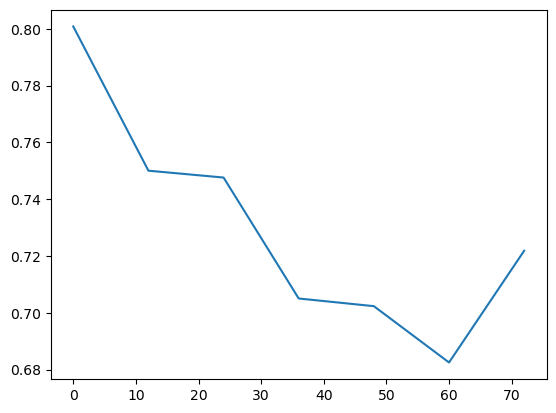

In [9]:
pd.Series({tau: metrics.roc_auc_score(p[0,:],p[1,:]) for tau, p in predictions_by_delay.items()}).plot()

<Axes: >

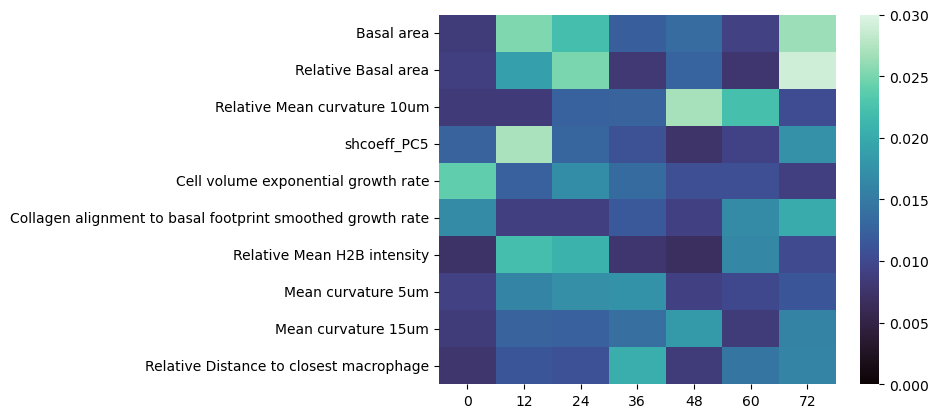

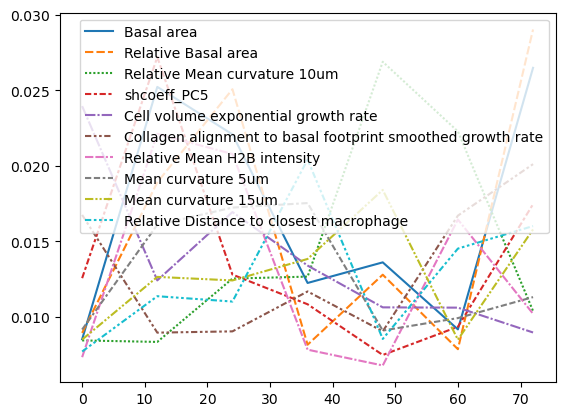

In [10]:
importances_mean.to_pickle(path.join(model_dir,'importances_mean.pkl'))
sorted_imps = importances_mean.mean(axis=1).sort_values(ascending=False)

sb.heatmap(importances_mean.loc[sorted_imps.head(10).index].droplevel(axis=0,level=1).astype(float),vmin=0,vmax=0.03,
           cmap='mako')

plt.figure()
sb.lineplot(importances_mean.loc[sorted_imps.head(10).index].droplevel(axis=0,level=1).astype(float).T)


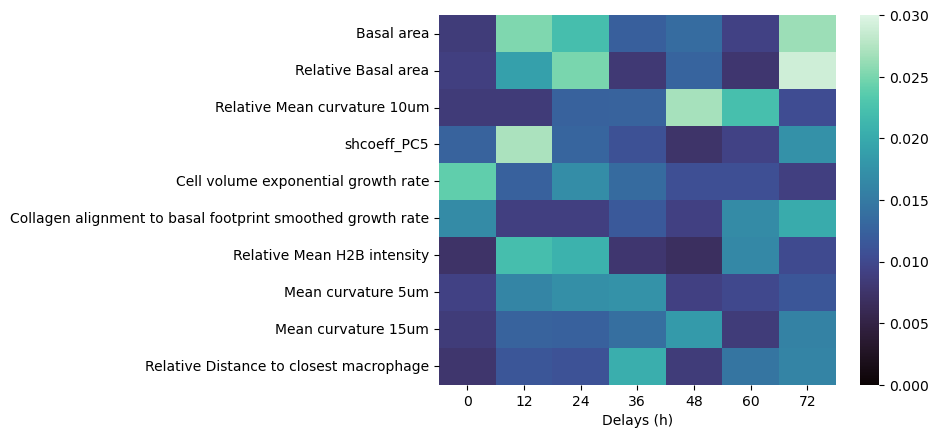

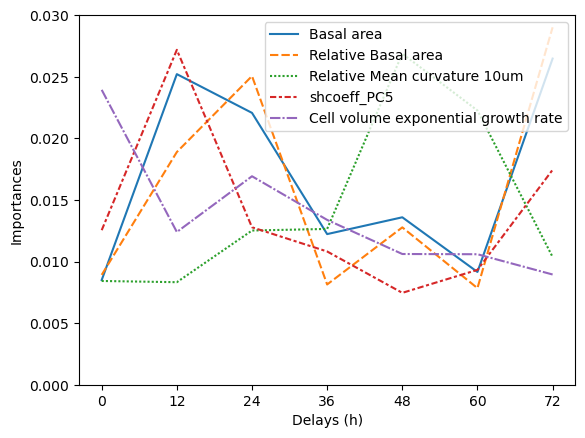

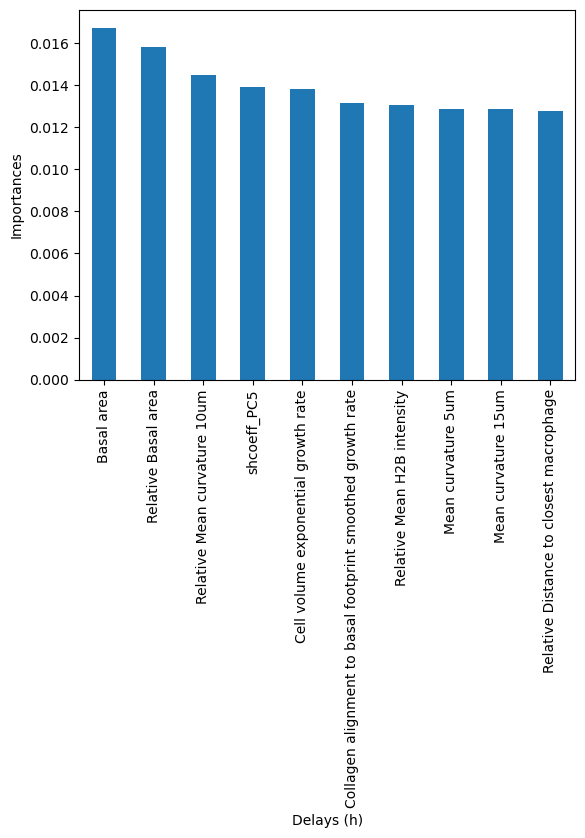

In [11]:
sorted_imps = importances_mean.mean(axis=1).sort_values(ascending=False)

sb.heatmap(importances_mean.loc[sorted_imps.head(10).index].droplevel(axis=0,level=1).astype(float),vmin=0,vmax=0.03,
           cmap='mako')
plt.xlabel('Delays (h)')
plt.savefig(path.join(model_dir,'top5_mean_importances_by_delay_heatmap.svg'))

plt.figure()
sb.lineplot(importances_mean.loc[sorted_imps.head(5).index].droplevel(axis=0,level=1).astype(float).T)
plt.xlabel('Delays (h)')
plt.ylabel('Importances')
plt.ylim([0,.03])
plt.gca().set_xticks([0,12,24,36,48,60,72])
plt.savefig(path.join(model_dir,'top5_mean_importances_by_delay.svg'))

plt.figure()
sorted_imps.head(10).droplevel(axis=0,level=1).plot.bar()
plt.xlabel('Delays (h)')
plt.ylabel('Importances')
plt.savefig(path.join(model_dir,'sorted_mean_importances.svg'))
